# Sequencial  Workflow 

In [66]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [67]:
#define class 
class BMI(TypedDict):
    weight: float
    height: float
    bmi: float 
    category : str 

In [68]:
#function calculate BMI 
def bmi_calculator(state: BMI) -> BMI:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height **2 )

    #upate state 

    state['bmi'] = round(bmi, 2)

    return state



In [69]:
def bmi_cat(state: BMI) -> BMI:
    bmi = state['bmi']

    if bmi < 18.5 :
        state["category"] = 'Underweight'
    elif 18.5 <= bmi < 25 :
        state["category"] = 'Normal weight'
    elif 25 <= bmi < 30 :
        state["category"] = 'Overweight'
    else :
        state["category"] = 'Obesity'
    return state

In [70]:
#define graph

graph = StateGraph(BMI)

#define nodes

graph.add_node("Calculate BMI",bmi_calculator)
graph.add_node("Category " , bmi_cat)

#define edges 

graph.add_edge(START,"Calculate BMI")
graph.add_edge("Calculate BMI","Category ")
graph.add_edge("Category ",END)

#define complile 
workflow = graph.compile()

In [71]:
# execute workflow

initial_State = {"weight": 70.0, "height": 1.75}

final_State  = workflow.invoke(initial_State)

print(final_State)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


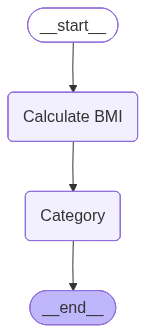

In [72]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

# LLM Workflow

In [73]:
import os 
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace


In [74]:
#load environment 
load_dotenv()

True

In [75]:
#check token 
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")

Done


In [76]:
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)

In [77]:
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

In [78]:
#state 

class LLMstate(TypedDict):
    question : str 
    answer : str 

In [79]:
def llm_ans(state : LLMstate) -> LLMstate:
    question = state['question']
    prompt = f"Answer the question : {question}"
    answer  = model.invoke(prompt).content
    state['answer'] = answer
    return state

In [80]:
# graph 

graph = StateGraph(LLMstate)
# nodes 
graph.add_node("LLM_ans" , llm_ans)
# edges 
graph.add_edge(START,"LLM_ans")
graph.add_edge("LLM_ans",END)
# complile 
workflow = graph.compile()

In [81]:
# execute workflow

initial_state = {"question": "What is the capital of France?"}
final_State = workflow.invoke(initial_state)
print(final_State['answer'])

The capital of France is Paris.


# Prompt Chaining Workflow

In [82]:
class BlogState(TypedDict):
    title : str 
    content : str 
    outline: str 

In [83]:
def generate_outline(state : BlogState) -> BlogState:
    title = state['title']
    prompt = f"Generate an outline for a blog post with the title : {title}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [84]:
def generate_blog(state : BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f"Generate a blog have title {title} post based on the following outline : {outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [85]:
#graph 
graph = StateGraph(BlogState)
#nodes 
graph.add_node("Generate Outline" , generate_outline)
graph.add_node("Generate Blog" , generate_blog)
#edges 
graph.add_edge(START , "Generate Outline")
graph.add_edge("Generate Outline" , "Generate Blog")
graph.add_edge("Generate Blog" , END)
#compile 
workflow = graph.compile()

In [86]:
initial_state_gb = {"title": "The Benefits of AI in Healthcare"}
fs_gb = workflow.invoke(initial_state_gb)
print("Outline : ", fs_gb['outline'])
print("Content : ", fs_gb['content'])

Outline :  Here's a suggested outline for a blog post on "The Benefits of AI in Healthcare":

**I. Introduction**

* Brief overview of the increasing role of Artificial Intelligence (AI) in healthcare
* Importance of AI in transforming the healthcare industry
* Thesis statement: AI has the potential to revolutionize healthcare by improving patient outcomes, enhancing efficiency, and reducing costs.

**II. Improved Diagnosis and Treatment**

* How AI algorithms can analyze medical images and patient data to identify potential health issues
* Examples of AI-powered diagnostic tools, such as:
	+ Image recognition software for cancer detection
	+ Predictive analytics for chronic disease management
* Discussion of how AI can help clinicians diagnose diseases more accurately and early

**III. Enhanced Patient Care**

* How AI-powered chatbots and virtual assistants can improve patient engagement and education
* Examples of AI-driven patient support systems, such as:
	+ Personalized health co

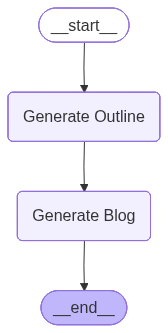

In [87]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())